In [1]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
class GridWorld2:
    def __init__(self, states, actions, rewards, n, alpha, discount, epsilon):
        self.states = states
        self.actions = actions
        self.n = n
        self.epsilon = epsilon
        self.alpha = alpha
        self.discount = discount
        self.rewards = rewards
        self.q_table = {state: {action: 0.0 for action in actions} for state in states}
    def reset(self):
        return (0, 0)
    def is_terminal(self, state):
        return state not in self.states
    def trans(self, state, action):
        new_state = (state[0] + action[0], state[1] + action[1])
        if new_state[0] < 0 or new_state[0] >= self.n or new_state[1] < 0 or new_state[1] >= self.n:
            return state
        return new_state
    def find_max_q(self, state):
        if state in self.q_table:
            return max(self.q_table[state].values())
        return 0.0 
    def choose_action(self, state):
        if np.random.rand() < self.epsilon: return self.actions[np.random.randint(len(self.actions))]
        else: return max(self.q_table[state], key=self.q_table[state].get)
    def solve(self, num_episodes=1000, max_steps=50):
        decay = 0.999
        total_rewards = []
        first_success = None
        for episode in range(num_episodes):
            state = self.reset()
            total_reward = 0
            for step in range(max_steps):
                action = self.choose_action(state)
                new_state = self.trans(state, action)
                reward = self.rewards.get(new_state, 0)
                old_value = self.q_table[state][action]
                if new_state == (0,3):
                    max_future_q = 0
                else:
                    max_future_q = self.find_max_q(new_state)
                new_value = old_value + self.alpha * (
                    reward + self.discount * max_future_q - old_value
                )
                self.q_table[state][action] = new_value
                state = new_state
                total_reward += reward
                goal = (0, 3)
                if state == goal:
                    if first_success is None:
                        first_success = episode
                    break
            total_rewards.append(total_reward)
            self.epsilon *= decay
        return self.q_table, total_rewards, first_success


In [34]:
states = []
rewards = {}
for x in range(4):
    for y in range(4):
        states.append((x , y))
        state = (x , y)
        if(x==0 and y==3): rewards[state] = 10
        elif(x==1 and y==3): rewards[state] = -1
        else: rewards[state] = -0.04
actions = [(-1 , 0) , (0 , 1) , (0 , -1) , (1,  0)]
gw = GridWorld2(states , actions , rewards , 4 , 0.9 , 0.99 , 0.2)
ans = gw.solve()

In [31]:
print("Q-table")
rows = []
ans = ans[0]
for state in states:
    entry = []
    for action in actions:
        entry.append(ans[state].get(action , None))
    rows.append(entry)
print(pd.DataFrame(rows ,   columns = actions , index = states))
start_state = (3 , 0)
path = [start_state]
for _ in range(6):
    act = max(list(ans[start_state].keys()) , key = lambda x: ans[start_state][x])
    start_state = (start_state[0]+act[0] , start_state[1]+act[1])
    path.append(start_state)
    if(start_state[0]==0 and start_state[1]==3): break
s = ""
for i in range(len(path)):
    s+=(f"{path[i]} ->")
print("Path: " , s[:-2])

Q-table
         (-1, 0)     (0, 1)   (0, -1)    (1, 0)
(0, 0)  9.584186   9.721400  9.584186  9.448344
(0, 1)  9.721400   9.860000  9.584186  9.584186
(0, 2)  9.860000  10.000000  9.721400  9.721400
(0, 3)  0.000000   0.000000  0.000000  0.000000
(1, 0)  9.584186   8.622167  8.502650  7.540627
(1, 1)  9.721400   8.745660 -0.036000  7.642355
(1, 2)  9.860000  -9.000000  0.000000 -0.039600
(1, 3)  0.000000   0.000000  8.749260  0.000000
(2, 0)  9.353861   0.000000  0.000000  0.000000
(2, 1)  9.487984  -0.036000 -0.036000 -0.036000
(2, 2)  8.743987  -0.036000 -0.036000 -0.036000
(2, 3)  0.000000   0.000000 -0.036000  0.000000
(3, 0)  0.000000   0.000000  0.000000  0.000000
(3, 1) -0.068076   0.000000  0.000000  0.000000
(3, 2) -0.068076   0.000000  0.000000  0.000000
(3, 3)  0.000000   0.000000  0.000000  0.000000
Path:  (3, 0) ->(2, 0) ->(1, 0) ->(0, 0) ->(0, 1) ->(0, 2) ->(0, 3) 


In [108]:
print("Q-table")
rows = []
for state in states:
    entry = []
    for action in actions:
        entry.append(ans[state].get(action , None))
    rows.append(entry)
print(pd.DataFrame(rows ,   columns = actions , index = states))
start_state = (3 , 0)
path = [start_state]
for _ in range(6):
    act = max(list(ans[start_state].keys()) , key = lambda x: ans[start_state][x])
    start_state = (start_state[0]+act[0] , start_state[1]+act[1])
    path.append(start_state)
    if(start_state[0]==0 and start_state[1]==3): break
s = ""
for i in range(len(path)):
    s+=(f"{path[i]} ->")
print("Path: " , s[:-2])

Q-table
           (-1, 0)      (0, 1)     (0, -1)      (1, 0)
(0, 0)  969.850814  979.659262  969.861579  959.714933
(0, 1)  979.483337  989.563556  969.656729  969.731306
(0, 2)  989.524882  999.566694  979.612248  979.660975
(0, 3)  999.567091  999.214160  989.447863  988.488050
(1, 0)  969.862622  969.761511  960.162383  950.537572
(1, 1)  979.612346  979.663123  960.120183  960.145416
(1, 2)  989.563119  988.559519  969.865606  969.782691
(1, 3)  999.570987  988.038828  979.652596  978.637021
(2, 0)  960.126805  960.167508  950.462248  941.033924
(2, 1)  969.866478  969.819543  950.255935  950.469891
(2, 2)  979.667444  978.547477  960.060361  959.616755
(2, 3)  988.570987  978.048943  969.868031  968.867387
(3, 0)  950.417125  950.554704  940.934815  941.044556
(3, 1)  960.084742  960.168749  940.999595  950.508008
(3, 2)  969.870575  968.868325  950.554072  960.150497
(3, 3)  978.685234  968.594569  960.139900  968.824484
Path:  (3, 0) ->(3, 1) ->(3, 2) ->(2, 2) ->(1, 2) ->(0, 2

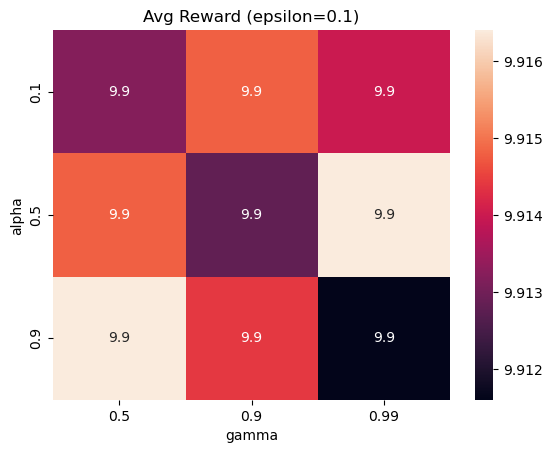

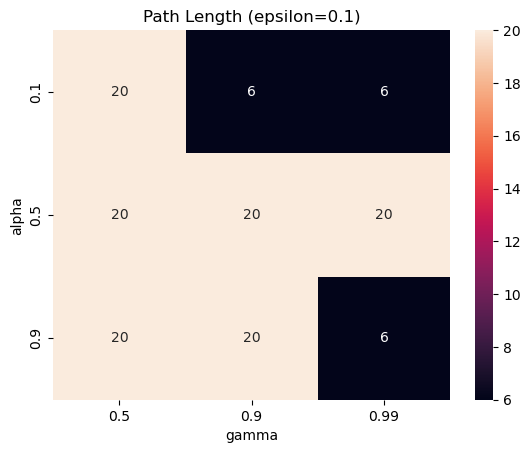

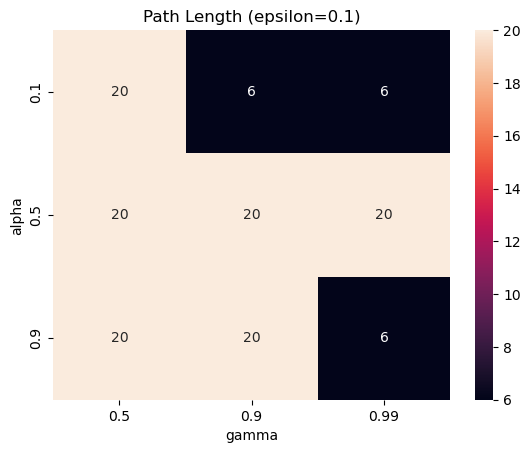

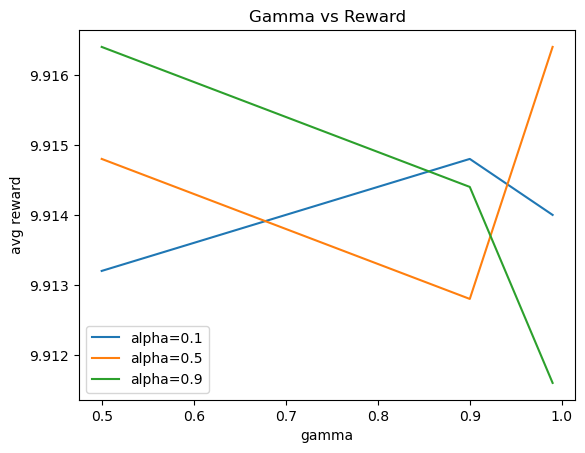

In [36]:
def get_path_length(q_table, actions, gw, start=(3,0), goal=(0,3), max_steps=20):
    state = start
    steps = 0
    for _ in range(max_steps):
        if state not in q_table:
            return max_steps 
        action = max(q_table[state], key=lambda x: q_table[state][x])
        state = gw.trans(state, action)
        steps += 1
        if state == goal:
            return steps
    return max_steps
alphas = [0.1, 0.5, 0.9]
gammas = [0.5, 0.9, 0.99]
epsilons = [0.01, 0.1, 0.2]
results = []
for alpha, gamma, epsilon in itertools.product(alphas, gammas, epsilons):
    gw = GridWorld2(states, actions, rewards, 4, alpha, gamma, epsilon)
    q_table, rewards_list, first_success = gw.solve()
    avg_last_100 = np.mean(rewards_list[-100:])
    path_len = get_path_length(q_table, actions , gw)

    results.append({
        "alpha": alpha,
        "gamma": gamma,
        "epsilon": epsilon,
        "first_success": first_success if first_success is not None else 1000,
        "avg_reward": avg_last_100,
        "path_length": path_len
    })
df = pd.DataFrame(results)
import seaborn as sns
eps = 0.1 
subset = df[df["epsilon"] == eps]
pivot = subset.pivot(index="alpha", columns="gamma", values="avg_reward")
plt.figure()
sns.heatmap(pivot, annot=True)
plt.title(f"Avg Reward (epsilon={eps})")
plt.show()
pivot2 = subset.pivot(index="alpha", columns="gamma", values="path_length")
plt.figure()
sns.heatmap(pivot2, annot=True)
plt.title(f"Path Length (epsilon={eps})")
plt.show()
pivot2 = subset.pivot(index="alpha", columns="gamma", values="path_length")
plt.figure()
sns.heatmap(pivot2, annot=True)
plt.title(f"Path Length (epsilon={eps})")
plt.show()
for alpha in alphas:
    subset = df[(df["alpha"] == alpha) & (df["epsilon"] == 0.1)]
    plt.plot(subset["gamma"], subset["avg_reward"], label=f"alpha={alpha}")

plt.xlabel("gamma")
plt.ylabel("avg reward")
plt.legend()
plt.title("Gamma vs Reward")
plt.show()